In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('../data/dataset.tsv', sep='\t', header=None)
print(df.shape)
print(df.head())

(582390, 4)
      0                                                 1        2  \
0  1276                              Let's try something.       77   
1  1276                              Let's try something.   392932   
2  1276                              Let's try something.  1674110   
3  1280  Today is June 18th and it is Muiriel's birthday!       81   
4  1280  Today is June 18th and it is Muiriel's birthday!  1674125   

                                                   3  
0                          Lass uns etwas versuchen!  
1                      Lasst uns etwas ausprobieren!  
2                     Lass uns mal was ausprobieren.  
3  Heute ist der 18. Juni und das ist der Geburts...  
4  Heute ist der achtzehnte Juni — und Muiriels G...  


In [4]:
df.columns = ['sentence_id', 'english', 'translation_id', 'german']
df_pairs = df[['english', 'german']].drop_duplicates()
print(df_pairs.shape)
print(df_pairs.head())

(582387, 2)
                                            english  \
0                              Let's try something.   
1                              Let's try something.   
2                              Let's try something.   
3  Today is June 18th and it is Muiriel's birthday!   
4  Today is June 18th and it is Muiriel's birthday!   

                                              german  
0                          Lass uns etwas versuchen!  
1                      Lasst uns etwas ausprobieren!  
2                     Lass uns mal was ausprobieren.  
3  Heute ist der 18. Juni und das ist der Geburts...  
4  Heute ist der achtzehnte Juni — und Muiriels G...  


In [6]:
df_pairs['en_len'] = df_pairs['english'].str.split().str.len()
df_pairs['de_len'] = df_pairs['german'].str.split().str.len()
print(df_pairs[['en_len', 'de_len']].describe())

              en_len         de_len
count  582387.000000  582387.000000
mean        6.926367       6.910985
std         5.124022       3.649231
min         1.000000       1.000000
25%         5.000000       5.000000
50%         6.000000       6.000000
75%         8.000000       8.000000
max      2720.000000     220.000000


After filtering: 582121 pairs (100.0% retained)


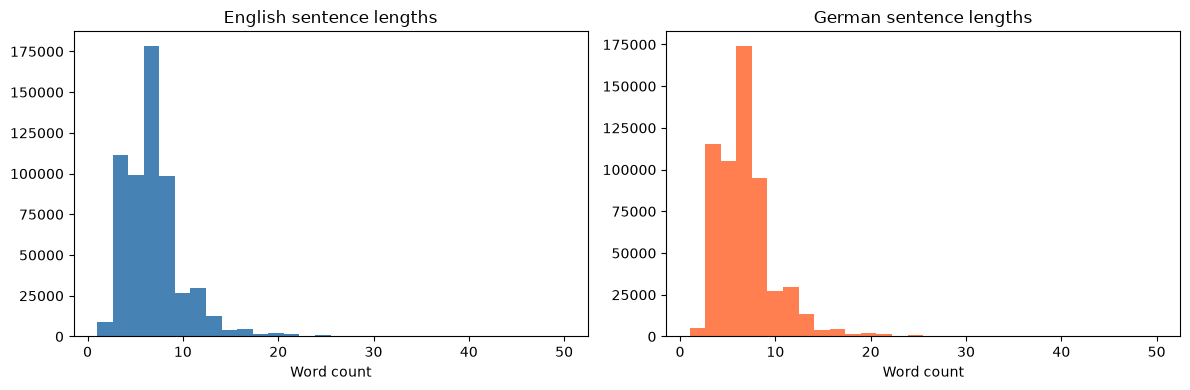

Saved to dataset_clean.tsv


In [7]:
df_clean = df_pairs[(df_pairs['en_len'] <= 50) & (df_pairs['de_len'] <= 50)]
print(f"After filtering: {len(df_clean)} pairs ({len(df_clean)/len(df_pairs)*100:.1f}% retained)")

# Length distribution plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_clean['en_len'], bins=30, color='steelblue')
axes[0].set_title('English sentence lengths')
axes[0].set_xlabel('Word count')
axes[1].hist(df_clean['de_len'], bins=30, color='coral')
axes[1].set_title('German sentence lengths')
axes[1].set_xlabel('Word count')
plt.tight_layout()
plt.show()

# Save clean dataset
df_clean[['english', 'german']].to_csv('../data/dataset_clean.tsv', sep='\t', index=False)
print("Saved to dataset_clean.tsv")